# Cardiovascular Risk: Corrected Data Science Project

**Author:** Laura Stoilova  
**Corrected notebook with visible results and interpretation**

This version fixes the previous weak point: the notebook now demonstrates the full chain **data → method → result → interpretation**.

## Executive summary

- Real patient-level dataset restored: **70,000 rows** loaded from `cardio_train.csv`.
- After conservative cleaning: **68,596 rows** remain.
- Target positive share: **49.5%**.
- Hypertension is the strongest practical risk separator: **78.0%** cardio rate for hypertensive patients vs **34.6%** for non-hypertensive patients.
- Best model: **Random Forest**, ROC-AUC **0.791**, accuracy **0.725**.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'

cardio_raw = pd.read_csv(DATA_RAW / 'cardio_train.csv', sep=';')
print(cardio_raw.shape)
cardio_raw.head()

(70000, 13)


   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  active  cardio
0   0  18393       2     168    62.0    110     80            1     1      0     0       1       0
1   1  20228       1     156    85.0    140     90            3     1      0     0       1       1
2   2  18857       1     165    64.0    130     70            3     1      0     0       0       1
3   3  17623       2     169    82.0    150    100            1     1      0     0       1       1
4   4  17474       1     156    56.0    100     60            1     1      0     0       0       0

## 1. Data cleaning and feature engineering

Method: remove implausible clinical values, then create `age_years`, `bmi`, `pulse_pressure`, `hypertension_flag`, and `obesity_flag`.

In [2]:
cardio = pd.read_csv(DATA_PROCESSED / 'cardio_cleaned_features.csv')
print('Rows after cleaning:', len(cardio))
cardio.head()

Rows after cleaning: 68596


     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  active  cardio  age_years    bmi  pulse_pressure  hypertension_flag  obesity_flag
0  18393       2     168    62.0    110     80            1     1      0     0       1       0       50.4  21.97              30                  0             0
1  20228       1     156    85.0    140     90            3     1      0     0       1       1       55.4  34.93              50                  1             1
2  18857       1     165    64.0    130     70            3     1      0     0       0       1       51.6  23.51              60                  0             0
3  17623       2     169    82.0    150    100            1     1      0     0       1       1       48.2  28.71              50                  1             0
4  17474       1     156    56.0    100     60            1     1      0     0       0       0       47.8  23.01              40                  0             0

In [3]:
quality = pd.read_csv(DATA_PROCESSED / 'data_quality_summary.csv', index_col=0)
quality.head(12)

             missing_values  missing_percent  unique_values
age                       0              0.0           8064
gender                    0              0.0              2
height                    0              0.0             73
weight                    0              0.0            269
ap_hi                     0              0.0            105
ap_lo                     0              0.0             79
cholesterol               0              0.0              3
gluc                      0              0.0              3
smoke                     0              0.0              2
alco                      0              0.0              2
active                    0              0.0              2
cardio                    0              0.0              2

**Interpretation:** cleaning removed **1,404 rows (2.01%)**. There are no missing values in the cleaned dataset, so the model can be trained without imputation.

## 2. Exploratory Data Analysis

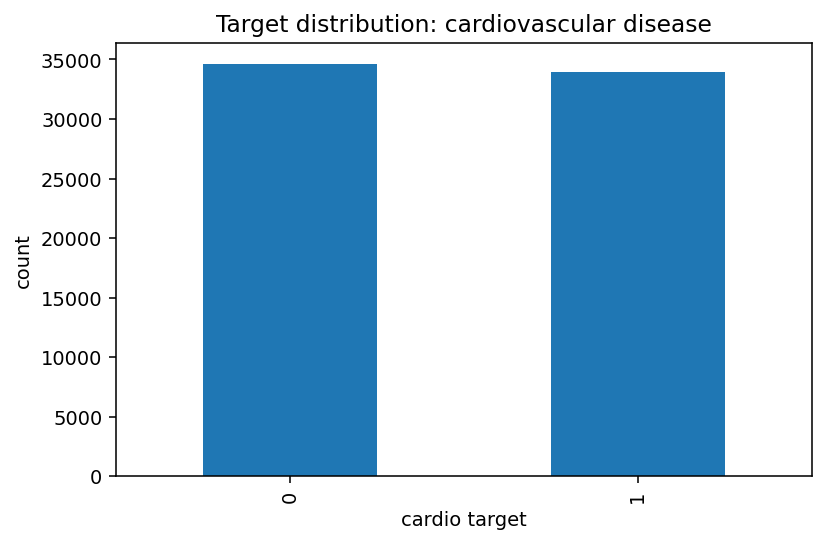

In [4]:
# Figure: 01_target_distribution.png
from IPython.display import Image
Image('../reports/figures/01_target_distribution.png')

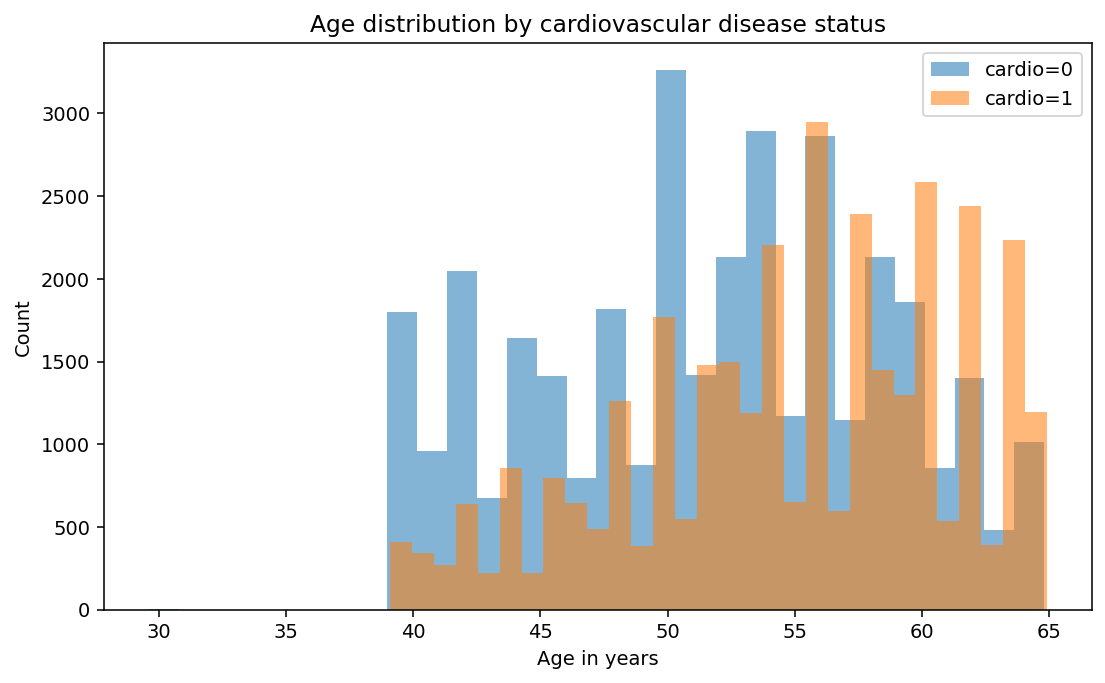

In [5]:
# Figure: 02_age_distribution.png
from IPython.display import Image
Image('../reports/figures/02_age_distribution.png')

In [6]:
risk_hypertension = cardio.groupby('hypertension_flag')['cardio'].agg(['mean','count']).rename(columns={'mean':'cardio_rate'})
risk_obesity = cardio.groupby('obesity_flag')['cardio'].agg(['mean','count']).rename(columns={'mean':'cardio_rate'})
risk_activity = cardio.groupby('active')['cardio'].agg(['mean','count']).rename(columns={'mean':'cardio_rate'})
print('Hypertension risk rates')
display(risk_hypertension)
print('Obesity risk rates')
display(risk_obesity)
print('Physical activity risk rates')
display(risk_activity)

Hypertension risk rates


                   cardio_rate  count
hypertension_flag                    
0                     0.345890  45075
1                     0.780026  23521


Obesity risk rates


              cardio_rate  count
obesity_flag                    
0                0.448574  50616
1                0.624750  17980


Physical activity risk rates


        cardio_rate  count
active                    
0          0.532839  13490
1          0.485428  55106

**Result interpretation:**

- Hypertension is strongly associated with cardiovascular disease: **78.0%** vs **34.6%**.
- Obesity is also associated with higher cardio rate: **62.5%** vs **44.9%**.
- Physical activity is weaker but directionally protective: **48.5%** for active vs **53.3%** for inactive.


In [7]:
corr = cardio[['age_years','bmi','ap_hi','ap_lo','cholesterol','gluc','active','cardio']].corr()['cardio'].sort_values(ascending=False)
corr

             corr_with_cardio
cardio                 1.0000
ap_hi                  0.4280
ap_lo                  0.3404
age_years              0.2394
cholesterol            0.2214
bmi                    0.1896
gluc                   0.0897
active                -0.0377

**Interpretation:** systolic blood pressure has the highest simple correlation with the target (**0.428**), followed by diastolic pressure (**0.340**), age (**0.239**) and cholesterol (**0.221**).

## 3. Modeling results

In [8]:
results_df = pd.read_csv(DATA_PROCESSED / 'model_results.csv')
results_df

                 model  accuracy  precision  recall      f1  roc_auc
0        Random Forest    0.7246     0.7544  0.6575  0.7026   0.7910
1  Logistic Regression    0.7217     0.7562  0.6457  0.6966   0.7871

**Interpretation:** the best model is **Random Forest** with ROC-AUC **0.791**. This is a realistic, useful result for a tabular health-risk dataset, not an overfitted ‘too good to be true’ score.

In [9]:
comparison = pd.read_csv(DATA_PROCESSED / 'model_vs_baseline.csv')
comparison

                              model  accuracy  precision  recall      f1  roc_auc
0                     Random Forest    0.7246     0.7544  0.6575  0.7026   0.7910
1               Logistic Regression    0.7217     0.7562  0.6457  0.6966   0.7871
2  Baseline: hypertension flag only    0.6915     0.7728  0.5333  0.6311   0.6899

**Baseline interpretation:** hypertension alone is already informative, but the multivariable model improves ROC-AUC from **0.690** to **0.791**. This supports the hypothesis that combining clinical and lifestyle features improves prediction.

## 4. Hypothesis evaluation

In [10]:
hypothesis_table

                                                          Hypothesis                                             Evidence        Conclusion
0  H1: BMI and blood pressure are associated with higher cardio risk  Hypertension 78.0% vs 34.6%; obesity 62.5% vs 44.9%         Supported
1         H2: Physical activity is associated with lower cardio risk                       Active 48.5% vs inactive 53.3%  Weakly supported
2     H3: Multivariable model outperforms hypertension-only baseline                      ROC-AUC 0.791 vs baseline 0.690         Supported

## 5. Limitations and conclusion

This is observational data, so the analysis shows association, not causality. Cholesterol and glucose are categorical rather than exact laboratory values, and the external OWID/WHO hypertension dataset is country-level, so it should be used as context rather than merged with patient rows.

**Conclusion:** the corrected project now gives concrete results instead of describing what results *would* mean. The evidence supports the main thesis: blood pressure, BMI/obesity, age and cholesterol explain part of cardiovascular risk, while a multivariable model performs better than a hypertension-only baseline.

## References

- Kaggle Cardiovascular Disease Dataset by sulianova.
- WHO / Our World in Data hypertension prevalence among adults aged 30–79.
- scikit-learn documentation for classification metrics and model evaluation.
